# Momentum Strategy — Research Notebook

Use this notebook to experiment with different dates, universes, and parameters.  
Each section is independent — re-run any cell after changing a value.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # makes src/ importable from notebooks/

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import download_close
from src.signals import composite_signal, top_n_signal, risk_adjusted_signal
from src.backtest import run as run_backtest
from src.metrics import summary, drawdown_series

%matplotlib inline
plt.rcParams["figure.figsize"] = (13, 5)
print("Imports OK")

Imports OK


## 1. Configuration — change anything here

In [2]:
# ── Date range ────────────────────────────────────────────────
START = "2016-01-01"
END   = "2026-05-19"

# ── Universe ───────────────────────────────────────────────────
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM",
    "V",    "UNH",  "XOM",   "LLY",  "JNJ",  "WMT",  "MA",   "PG",
    "HD",   "MRK",  "AVGO",  "CVX",  "ABBV", "COST", "PEP",  "KO",
    "ADBE", "CRM",  "TMO",   "ACN",  "MCD",  "BAC",
]
BENCHMARK = "SPY"

# ── Signal ────────────────────────────────────────────────────
TOP_N          = 10      # how many stocks to hold
USE_TREND      = True    # require price > 200-day MA
USE_VOL_FILTER = True    # require annualised vol < 40%

# ── Backtest engine ───────────────────────────────────────────
SIZING         = "equal"   # "equal"  |  "vol_parity"
REBALANCE_FREQ = 21        # trading days between rebalances (21=monthly, 63=quarterly)
COST_BPS       = 10.0      # one-way transaction cost in basis points

print("Config set.")

Config set.


## 2. Download Data

In [3]:
close_all = download_close(TICKERS + [BENCHMARK], start=START, end=END)
close      = close_all[TICKERS].dropna(how="all", axis=1)
bench      = close_all[BENCHMARK]

print(f"Tickers:    {len(close.columns)}")
print(f"Date range: {close.index[0].date()} → {close.index[-1].date()}")
print(f"Rows:       {len(close)}")
close.tail(3)

Tickers:    30
Date range: 2016-01-04 → 2026-05-18
Rows:       2608


Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,META,TSLA,JPM,V,UNH,...,ABBV,COST,PEP,KO,ADBE,CRM,TMO,ACN,MCD,BAC
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-14,298.209991,408.545135,401.070007,267.220001,235.740005,618.429993,443.299988,299.910004,322.519989,399.089996,...,210.770004,1041.250000,148.669998,80.449997,237.009995,167.580002,448.209991,163.990005,274.970001,49.849998
2026-05-15,300.230011,421.008148,396.779999,264.140015,225.320007,614.229980,422.239990,297.809998,325.750000,393.850006,...,210.389999,1048.949951,149.119995,80.820000,247.600006,173.509995,438.339996,168.820007,276.390015,49.770000
2026-05-18,297.839996,422.624664,396.940002,264.859985,222.320007,611.210022,409.989990,300.730011,332.640015,391.130005,...,209.410004,1076.469971,149.059998,81.199997,255.639999,179.479996,442.000000,177.550003,282.470001,50.689999


## 3. Generate Signals & Run Backtest

In [4]:
signal = composite_signal(close, n=TOP_N, use_trend_filter=USE_TREND, use_vol_filter=USE_VOL_FILTER)
result = run_backtest(close, signal, sizing=SIZING, rebalance_freq=REBALANCE_FREQ, cost_bps=COST_BPS)

bench_returns = bench.pct_change().reindex(result.returns.index)
print("Backtest complete.")

Backtest complete.


## 4. Performance Metrics

In [5]:
strat  = summary(result.returns, benchmark=bench_returns)
strat.name = "Momentum"
bench_s = summary(bench_returns)
bench_s.name = "SPY (B&H)"

pd.concat([strat, bench_s], axis=1)

,Momentum,SPY (B&H)
Total Return,524.37%,334.73%
CAGR,19.36%,15.26%
Annualised Vol,19.29%,17.87%
Sharpe Ratio,1.01,0.88
Sortino Ratio,1.18,1.07
Max Drawdown,-33.55%,-33.72%
Calmar Ratio,0.58,0.45
Win Rate,50.92%,55.41%
Profit Factor,1.22,1.19
VaR (95%),1.79%,1.68%


## 5. Equity Curve & Drawdown

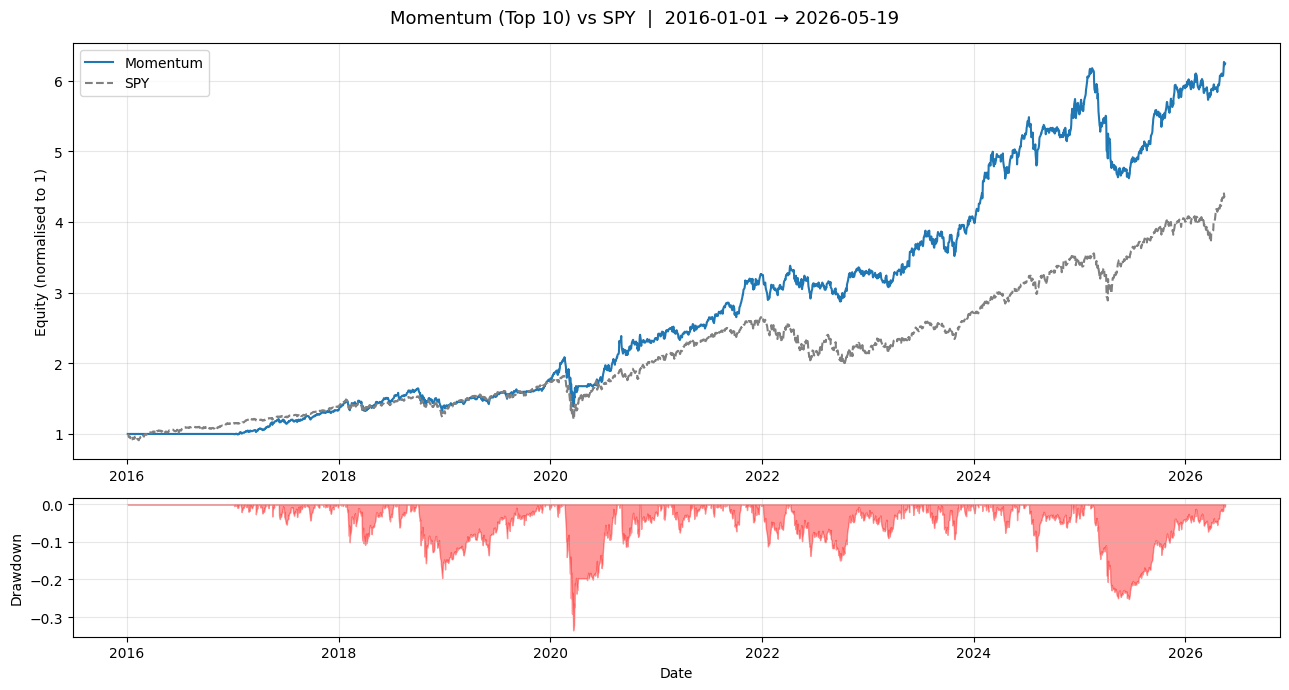

In [6]:
bench_equity = (1 + bench_returns).cumprod()
dd = drawdown_series(result.returns)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle(f"Momentum (Top {TOP_N}) vs SPY  |  {START} → {END}", fontsize=13)

axes[0].plot(result.equity,  label="Momentum", linewidth=1.5)
axes[0].plot(bench_equity,   label="SPY",       linewidth=1.5, linestyle="--", color="gray")
axes[0].set_ylabel("Equity (normalised to 1)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(dd.index, dd.values, 0, color="red", alpha=0.4, label="Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Compare Two Parameter Sets Side by Side

In [7]:
# Change either set of params and re-run this cell to compare
configs = {
    "Top 10 / Monthly":   dict(n=10, rebalance_freq=21,  cost_bps=10),
    "Top 5  / Quarterly": dict(n=5,  rebalance_freq=63,  cost_bps=10),
}

results = {}
for label, cfg in configs.items():
    sig = composite_signal(close, n=cfg["n"], use_trend_filter=USE_TREND, use_vol_filter=USE_VOL_FILTER)
    res = run_backtest(close, sig, sizing=SIZING, rebalance_freq=cfg["rebalance_freq"], cost_bps=cfg["cost_bps"])
    results[label] = res

# Metrics table
metrics_list = []
for label, res in results.items():
    s = summary(res.returns, benchmark=bench_returns)
    s.name = label
    metrics_list.append(s)
pd.concat(metrics_list, axis=1)

,Top 10 / Monthly,Top 5 / Quarterly
Total Return,524.37%,238.06%
CAGR,19.36%,12.49%
Annualised Vol,19.29%,23.95%
Sharpe Ratio,1.01,0.61
Sortino Ratio,1.18,0.73
Max Drawdown,-33.55%,-38.95%
Calmar Ratio,0.58,0.32
Win Rate,50.92%,47.74%
Profit Factor,1.22,1.13
VaR (95%),1.79%,2.22%


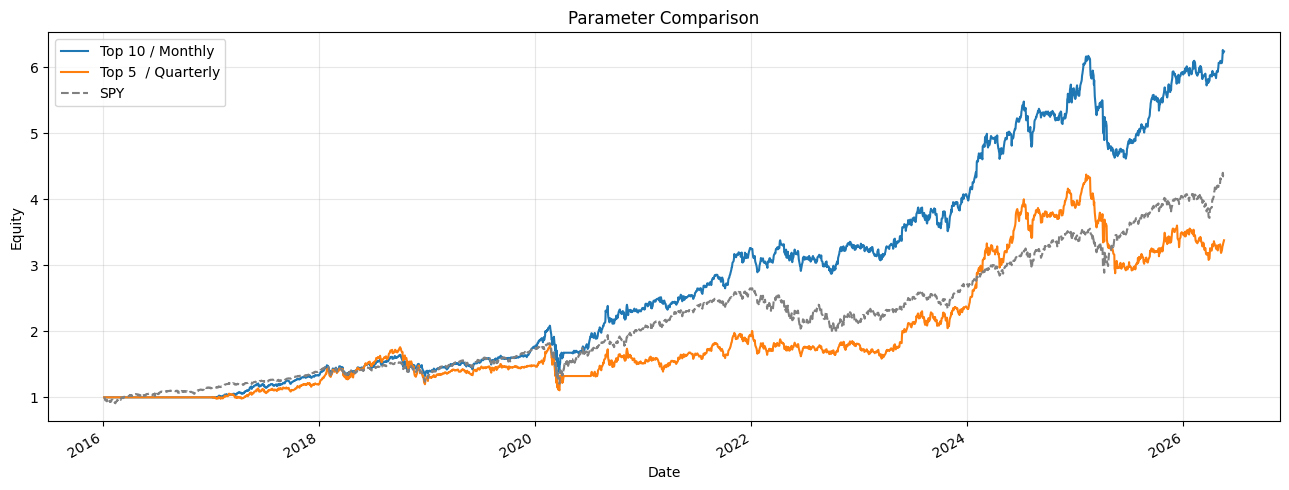

In [8]:
# Equity curves for both configs
fig, ax = plt.subplots(figsize=(13, 5))
for label, res in results.items():
    (1 + res.returns).cumprod().plot(ax=ax, label=label, linewidth=1.5)
(1 + bench_returns).cumprod().plot(ax=ax, label="SPY", linestyle="--", color="gray", linewidth=1.5)
ax.set_title("Parameter Comparison")
ax.set_ylabel("Equity")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Inspect Holdings — what stocks are being held?

Holdings as of 2026-05-18:

Ticker
AAPL    0.1
AMZN    0.1
NVDA    0.1
UNH     0.1
XOM     0.1
JNJ     0.1
WMT     0.1
MRK     0.1
AVGO    0.1
CVX     0.1


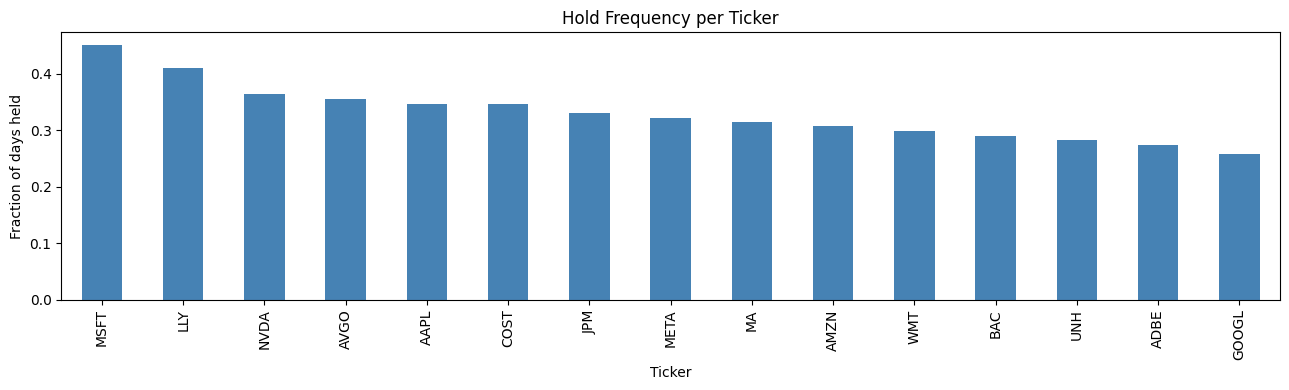

In [9]:
# Show the most recent portfolio holdings
latest_weights = result.weights.iloc[-1]
holdings = latest_weights[latest_weights > 0].sort_values(ascending=False)
print(f"Holdings as of {result.weights.index[-1].date()}:\n")
print(holdings.to_string())

# How often was each stock held?
hold_freq = (result.weights > 0).mean().sort_values(ascending=False)
hold_freq.head(15).plot(kind="bar", figsize=(13, 4), title="Hold Frequency per Ticker", color="steelblue")
plt.ylabel("Fraction of days held")
plt.tight_layout()
plt.show()